In [4]:
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os


from torchdiffeq import odeint

In [ ]:

import gc
import os
import sys
import time

import h5py
import mne
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from torchdiffeq import odeint, odeint_adjoint
import matplotlib.pyplot as plt

CONFIG = {

    "fif_path":  '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif',
    "mat_path":  "/home/shobs/Desktop/DDP/scout_id_309.mat",
    "sc_path":   "/home/shobs/Desktop/DDP/SC_CC120309-27.mat",

    "ecg_channel_idx": 322,      # raw channel index for ECG (inverted)
    "target_eeg_idx":  1,        # which EEG region to model
    "fs_raw":          1000,     # raw sampling rate  [Hz]
    "fs_model":        100,      # model sampling rate [Hz]
    "train_sec":       10,       # seconds used for training
    "test_sec":        5,        # seconds used for testing
    "start_idx":       2000,     # sample offset into the recording

    # ── Preprocessing ─────────────────────────────────────────────────────────
    "ecg_lowcut":  1.5,          # ECG bandpass low  [Hz]
    "ecg_highcut": 20.0,         # ECG bandpass high [Hz]
    "eeg_lowcut":  0.5,          # EEG bandpass low  [Hz]
    "eeg_highcut": 20.0,         # EEG bandpass high [Hz]
    "butter_order": 4,

    # ── Structural connectivity ───────────────────────────────────────────────
    "sc_scale":       0.01,       # SC matrix normalisation scale
    "sc_percentile":  60,        # sparsity threshold percentile
    "sc_osc_scale":   10.0,      # after expanding to oscillator resolution

    # ── Brain oscillator layout ───────────────────────────────────────────────
    "osc_per_region":  4,        # oscillators per brain region
    "freq_low_hz":     1.0,      # random freq lower bound [Hz]
    "freq_high_hz":   20.0,      # random freq upper bound [Hz]
    "intra_coupling":  0.0001,   # intra-region coupling strength
    "brain_seed":      42,

    # ── Heart oscillator (Stuart-Landau) ─────────────────────────────────────
    "heart_alpha":      1.0,
    "heart_omega1":     7.6,    # [rad/s]
    "heart_omega2":     7.7,     # [rad/s]
    "heart_A_init":     0.0001,
    "heart_theta_init": 3.14159265358979,   # np.pi
    "heart_n":          1.0,
    "heart_mod_scale":  0.1,     # modulation strength on heart oscillator

    # ── HeartModel MLP ───────────────────────────────────────────────────────
    "heart_input_dim":   4,
    "heart_hidden_dim":  100,
    "heart_feature_dim": 50,
    "heart_output_dim":  1,
    "heart_dropout":     0.1,

    # ── Stage 1 – heart training ──────────────────────────────────────────────
    "heart_epochs":      20000,
    "heart_lr":          1e-3,
    "heart_sched_factor":  0.5,
    "heart_sched_patience": 500,
    "heart_log_every":   2500,

    # ── Brain ODE (TorchRevHopf) ─────────────────────────────────────────────
    "brain_mu": 1.0,

    # ── Stage 1 – brain pre-train ─────────────────────────────────────────────
    "brain_epochs":      200,    # ↑ from 300 for better convergence
    "brain_lr_omega":    1e-2,
    "brain_lr_alpha":    1e-2,
    "brain_lr_theta":    1e-3,
    "brain_sched_factor":  0.5,
    "brain_sched_patience": 20,
    "brain_settle":      10,     # warmup steps to ignore
    "brain_corr_weight":  1.0,   # weight for correlation loss
    "brain_scale_weight": 0.1,   # weight for scale matching loss
    "brain_alpha_pen":    0.2,   # weight for alpha-collapse penalty
    "brain_grad_clip":    1.0,
    "brain_log_every":   50,

    # ── ECGToOscillatorMLP ────────────────────────────────────────────────────
    "vns_n_osc":    18,          # oscillators on the VNS pathway
    "vns_hidden":   64,
    "vns_seed":     42,
    "vns_sparsity": 0.3,

    # ── Stage 2 – ECG→Brain training ─────────────────────────────────────────
    "stage2_epochs":      200,   # ↑ from 300
    "stage2_lr":          5e-3,
    "stage2_sched_factor":  0.3,
    "stage2_sched_patience": 15,
    "stage2_sched_threshold": 1e-3,
    "stage2_sched_cooldown":  5,
    "stage2_min_lr":     1e-5,
    "stage2_settle_frac": 0.1,  # fraction of steps to skip in loss
    "stage2_grad_clip":   1.0,
    "stage2_log_every":  10,
    "brain_eta_omega": 0.05,
    "brain_eta_alpha": 0.03,
    "brain_eta_theta": 0.05,
    "stage2_alpha_lr":  1e-3,    # separate LR for learnable alpha in Stage 2
    "stage2_alpha_reg": 0.01,
    "stage2_hidden_noise": 0.01,

    # ── BrainToHeartFeedbackMLP ───────────────────────────────────────────────
    "feedback_n_vns":  12,
    "feedback_hidden": 64,
    "feedback_seed":   99,

    # ── Stage 4 – feedback training ───────────────────────────────────────────
    "stage4_epochs":        10,   # ↑ from 100 for better ECG test score
    "stage4_lr":            1e-3,
    "stage4_sched_factor":  0.5,
    "stage4_sched_patience": 20,
    "stage4_min_lr":        1e-5,
    "stage4_grad_clip":     1.0,
    "stage4_log_every":     20,
}

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20, order=4):
    """Detrend → bandpass → min-max normalise to [-1, 1]."""
    detrended = detrend(signal)
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    filtered = filtfilt(b, a, detrended)
    sig_min, sig_max = filtered.min(), filtered.max()
    denom = sig_max - sig_min
    if denom < 1e-10:
        return np.zeros_like(filtered)
    return 2.0 * (filtered - sig_min) / denom - 1.0

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total = num_regions * osc_per_region
    return 2 * np.pi * np.random.uniform(low, high, total)


def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            si, ei = i * osc_per_region, (i + 1) * osc_per_region
            sj, ej = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[si:ei, sj:ej] = intra_value
            else:
                blk = np.random.rand(osc_per_region, osc_per_region)
                blk *= Sc_region[i, j] / (blk.sum() + 1e-9)
                Sc_full[si:ei, sj:ej] = blk
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full


def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

class ZeroFeedback(nn.Module):
    def forward(self, x):
        T = x.shape[0] if x.dim() > 1 else 1
        return torch.zeros(T, 2, device=x.device)
# ──────────────────────────────────────────────────────────────────────────────
# Loss function
# ──────────────────────────────────────────────────────────────────────────────

class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        p = pred   - pred.mean()
        t = target - target.mean()
        num = (p * t).sum()
        den = torch.sqrt((p**2).sum() * (t**2).sum() + self.eps)
        return 1.0 - num / den


# ──────────────────────────────────────────────────────────────────────────────
# Heart sub-system ++ utility function
# ──────────────────────────────────────────────────────────────────────────────
def simulate_coupled_oscillators(T=10, dt=1/1000, alpha=1, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(T / dt)
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12 + (0.1*modulation[i,0] if modulation is not None and i < len(modulation) else 0)
        dr2 = alpha * r2 - r2**3 + coupling21 + (0.1*modulation[i,1] if modulation is not None and i < len(modulation) else 0)

        dphi1 = omega1 + A12 * r2 / r1 * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / r2 * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

class HeartModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg["heart_input_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Dropout(cfg["heart_dropout"]),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_feature_dim"]),
            nn.SiLU(),
        )
        self.output_layer = nn.Linear(cfg["heart_feature_dim"], cfg["heart_output_dim"])

    def forward(self, x):
        return torch.clamp(self.output_layer(self.feature_extractor(x)), -1.0, 1.0)

    def get_features(self, x):
        return self.feature_extractor(x)

class HeartOscillatorODEFunc(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.alpha      = cfg["heart_alpha"]
        self.A12        = cfg["heart_A_init"]
        self.A21        = cfg["heart_A_init"]
        self.n          = cfg["heart_n"]
        self.fs         = cfg["fs_model"]
        self.mod_scale  = cfg["heart_mod_scale"]
        self.omega1     = cfg["heart_omega1"]
        self.omega2     = cfg["heart_omega2"]
        self.modulation = None
        self.register_buffer("theta12", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))
        self.register_buffer("theta21", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))

    def forward(self, t, state):
        r1, phi1, r2, phi2 = state[0], state[1], state[2], state[3]
        r1 = torch.clamp(r1, 1e-6, 5.0)
        r2 = torch.clamp(r2, 1e-6, 5.0)

        c12 = self.A12 * r2 * torch.cos(self.theta12 + self.n * (phi2 - phi1))
        c21 = self.A21 * r1 * torch.cos(self.theta21 + self.n * (phi1 - phi2))

        if self.modulation is not None:
            t_idx = torch.clamp((t * self.fs).long(), 0, self.modulation.shape[0] - 1).item()
            mod   = self.modulation[t_idx]
            dr1   = (self.alpha - r1**2) * r1 + c12 + self.mod_scale * mod[0]
            dr2   = (self.alpha - r2**2) * r2 + c21 + self.mod_scale * mod[1]
        else:
            dr1 = (self.alpha - r1**2) * r1 + c12
            dr2 = (self.alpha - r2**2) * r2 + c21

        dphi1 = self.omega1 + self.A12 * (r2 / r1) * torch.sin(self.theta12 + self.n * (phi2 - phi1))
        dphi2 = self.omega2 + self.A21 * (r1 / r2) * torch.sin(self.theta21 + self.n * (phi1 - phi2))
        return torch.stack([dr1, dphi1, dr2, dphi2])


class HeartOscillatorLayer(nn.Module):
    """Differentiable coupled Stuart-Landau heart oscillator via ODE."""

    def __init__(self, cfg, device="cpu"):
        super().__init__()
        self.fs     = cfg["fs_model"]
        self.device = device
        self.ode_func = HeartOscillatorODEFunc(cfg)
        self.register_buffer("y0", torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32))

    def forward(self, T, modulation=None):
        self.ode_func.modulation = modulation
        t_eval = torch.arange(0, T, dtype=torch.float32, device=self.y0.device) / self.fs
        sol = odeint(self.ode_func, self.y0, t_eval, method="rk4")   # (T, 4)
        r1  = torch.clamp(sol[:, 0], 1e-6, 5.0)
        phi1 = sol[:, 1]
        r2  = torch.clamp(sol[:, 2], 1e-6, 5.0)
        phi2 = sol[:, 3]
        return torch.stack([
            r1 * torch.cos(phi1),
            r1 * torch.sin(phi1),
            r2 * torch.cos(phi2),
            r2 * torch.sin(phi2),
        ], dim=1)


# ──────────────────────────────────────────────────────────────────────────────
# VNS oscillator sub-layer (shared by ECGToOscillatorMLP & BrainToHeartFeedbackMLP)
# ──────────────────────────────────────────────────────────────────────────────

class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta):
        super().__init__()

        self.N_osc = N_osc
        self.mu = mu
        self.k = k

        self.register_buffer("omega", omega)
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)

        self.r_min = 0.001
        self.r_max = 2.0
        self.phase_clip = 2 * np.pi

        # self.input_f = None # Removed this as input_f will be passed via args to forward

    def forward(self, t, state):

        N = self.N_osc

        r = state[:N].unsqueeze(-1)
        phi = state[N:].unsqueeze(-1)

        # Dynamically get the input_f for the current time t from the sequence
        # Access input_features_sequence and t_eval_input from self
        if hasattr(self, 'input_features_sequence') and hasattr(self, 't_eval_input'):
            t_eval_input = self.t_eval_input
            input_features_sequence = self.input_features_sequence
            # Ensure t_eval_input and t are on the same device
            t_idx = torch.argmin(torch.abs(t_eval_input.to(t.device) - t)).long()
            input_f = input_features_sequence[t_idx].unsqueeze(-1) # (N_osc, 1)
        else:
            # Default to zero if no input sequence is provided (e.g., initial ODE func creation or debugging)
            input_f = torch.zeros_like(r) # (N_osc, 1)

        omega_i = self.omega.unsqueeze(-1)
        omega_j = self.omega.unsqueeze(0)

        C = self.C
        theta = self.theta

        phi_i = phi
        phi_j = phi.transpose(0, 1)

        phase_term = phi_j / omega_j - phi_i / omega_i + theta / (omega_i * omega_j)

        phase_term = torch.clamp(
            phase_term,
            -self.phase_clip,
            self.phase_clip
        )

        r_j = r.transpose(0, 1)
        r_safe = torch.clamp(r, self.r_min, self.r_max)

        coupling_r = self.k * torch.sum(
            C * r_j * torch.cos(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        coupling_phi = self.k * torch.sum(
            C * (r_j / r_safe) * torch.sin(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        dr_dt = (self.mu - r**2) * r + coupling_r + input_f
        dphi_dt = self.omega.unsqueeze(-1) + coupling_phi

        return torch.cat([
            dr_dt.squeeze(-1),
            dphi_dt.squeeze(-1)
        ])


class OscillatorLayer(nn.Module):

    def __init__(self,
                 N_osc=16,
                 T=4.0,
                 fs=100,
                 device="cpu",
                 coupling_sparsity=0.3,
                 seed=42):

        super().__init__()

        self.N_osc = N_osc
        self.T = T
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        self.mu_param = nn.Parameter(torch.tensor(1.0, device=device))
        self.k_param = nn.Parameter(torch.tensor(0.01, device=device))
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)

        mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)

        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.C_buffer = C_val * mask.float()

        theta_val = torch.zeros(N_osc, N_osc, device=device)
        theta_val.fill_diagonal_(0.0)
        self.theta_buffer = theta_val

        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer
        )

        self.register_buffer("initial_r", torch.ones(N_osc, device=device) * 0.1)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features_sequence):
        T_steps = input_features_sequence.shape[0]

        y0 = torch.cat([self.initial_r, self.initial_phi])

        t_eval = torch.arange(
            0, T_steps, device=input_features_sequence.device, dtype=torch.float32
        ) / self.fs

        self.ode_func.input_features_sequence = input_features_sequence
        self.ode_func.t_eval_input = t_eval

        sol = odeint(self.ode_func, y0, t_eval, method="rk4")

        del self.ode_func.input_features_sequence
        del self.ode_func.t_eval_input

        return sol



# ──────────────────────────────────────────────────────────────────────────────
# ECG → Brain drive MLP  (Stage 2)
# ──────────────────────────────────────────────────────────────────────────────

class ECGToOscillatorMLP(nn.Module):
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16,
                 device="cuda", coupling_sparsity=0.3, seed=42):  # ← add these
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device,
            coupling_sparsity=coupling_sparsity, seed=seed,  # ← use them
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        ecg_features = (
            ecg_features - ecg_features.mean(dim=-1, keepdim=True)
        ) / (ecg_features.std(dim=-1, keepdim=True) + 1e-6)

        pre = self.pre_osc(ecg_features)
        osc_hidden = self.osc_layer(pre) # Shape (T_steps, 2 * N_VNS)

        # Extract only the radius component from the oscillator state
        # osc_hidden contains [r1, ..., rN_VNS, phi1, ..., phiN_VNS]
        # The first N_VNS elements are radii
        r_components = osc_hidden[:, :self.osc_layer.N_osc]
        combined = r_components # Now combined has shape (T_steps, N_VNS)

        brain_drive = self.post_osc(combined)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive

def train_feedback_stage(trained_heart_model, trained_mlp_model,
                          heart_osc_layer, final_brain_params,
                          Sc_reduced_osc, N, D_full_func,
                          t_train, ecg_train_processed, cfg, device):
    print("\n--- Stage 4: Brain→Heart Feedback Training ---")

    feedback_mlp = BrainToHeartFeedbackMLP(
        brain_dim=N, N_VNS=cfg["feedback_n_vns"],
        hidden_dim=cfg["feedback_hidden"], device=device,
        seed=cfg["feedback_seed"],
    ).to(device)

    optimizer = torch.optim.Adam(
        list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
        lr=cfg["stage4_lr"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=cfg["stage4_sched_factor"],
        patience=cfg["stage4_sched_patience"], min_lr=cfg["stage4_min_lr"],
    )
    criterion    = CorrelationLoss()
    T_train      = len(t_train)
    target_ecg   = torch.tensor(
        ecg_train_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)
    D_full_train = D_full_func(t_train)
    losses       = []

    # Precompute frozen quantities once before loop
    with torch.no_grad():
        sim_plain   = heart_osc_layer(T_train, modulation=None).detach()
        hidden      = trained_heart_model.get_features(sim_plain).detach()
        brain_drive = torch.clamp(trained_mlp_model(hidden), -5.0, 5.0).detach()
        model_brain = TorchRevHopfNetwork(
            mu=cfg["brain_mu"], D_full=D_full_train, N=N,
            Sc=Sc_reduced_osc, brain_drive_full=brain_drive,
            fs=cfg["fs_model"], fixed_params=final_brain_params,
            device=device, learn_alpha=False,
        )
        r_br, phi_br, _, _, _, _ = model_brain.solve(
            final_brain_params["r"], final_brain_params["phi"],
            t_train, use_adjoint=False,
        )
        rcos_phi = (r_br * torch.cos(phi_br)).detach()

    for epoch in range(cfg["stage4_epochs"]):
        modulation    = feedback_mlp(rcos_phi)
        sim_modulated = heart_osc_layer(T_train, modulation=modulation)
        pred_ecg      = trained_heart_model(sim_modulated)
        loss          = criterion(pred_ecg.squeeze(), target_ecg.squeeze())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
            max_norm=cfg["stage4_grad_clip"],
        )
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())

        if (epoch + 1) % cfg["stage4_log_every"] == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"  Feedback Epoch {epoch+1:3d}/{cfg['stage4_epochs']}  "
                  f"Loss: {loss.item():.6f}  LR: {lr:.3e}")

    print("--- Stage 4 Finished ---")
    return feedback_mlp, losses


def save_with_splits(arr, name, region_dir, T_train):
    np.save(f"{region_dir}/{name}_full.npy",  arr)
    np.save(f"{region_dir}/{name}_train.npy", arr[:T_train])
    np.save(f"{region_dir}/{name}_test.npy",  arr[T_train:])


class BrainToHeartFeedbackMLP(nn.Module):
    def __init__(self, brain_dim, N_VNS=12, hidden_dim=64, device="cuda", seed=99):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.LayerNorm(brain_dim),
            nn.Linear(brain_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device, coupling_sparsity=0.3, seed=seed,
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, rcos_phi):
        if rcos_phi.dim() == 1:
            rcos_phi = rcos_phi.unsqueeze(0)
        pre        = self.pre_osc(rcos_phi)
        osc_hidden = self.osc_layer(pre)
        r_components = osc_hidden[:, :self.osc_layer.N_osc]
        return self.post_osc(r_components)
    

class ODEFuc(nn.Module):
    def __init__(self, mu, D_full, N, Sc, omega0, alpha0, theta0,
                 brain_drive_full=None, fs=100, fixed_params=None,
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0, learn_alpha=False):
        super().__init__()
        self.mu  = mu
        self.N   = N
        self.fs  = fs
        self.register_buffer("D_full", torch.tensor(D_full, dtype=torch.float32))
        self.register_buffer("Sc",     torch.tensor(Sc,     dtype=torch.float32))
        self.brain_drive_full = brain_drive_full
        self.fixed_params     = fixed_params
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.eta_theta = eta_theta
        self.learn_alpha = learn_alpha

        if fixed_params is not None:
            self.register_buffer("theta_fixed", torch.tensor(fixed_params["theta"], dtype=torch.float32))
            self.register_buffer("omega_fixed", torch.tensor(fixed_params["omega"], dtype=torch.float32))
            if learn_alpha:
                self.alpha_param = nn.Parameter(
                    torch.tensor(fixed_params["alpha"], dtype=torch.float32)
                )
            else:
                self.register_buffer("alpha_fixed", torch.tensor(fixed_params["alpha"], dtype=torch.float32))
        else:
            self.omega_param = nn.Parameter(torch.tensor(omega0, dtype=torch.float32))
            self.alpha_param = nn.Parameter(torch.tensor(alpha0, dtype=torch.float32))
            self.theta_param = nn.Parameter(torch.tensor(theta0, dtype=torch.float32))
        self.t0 = 0.0

    def forward(self, t, state):
        N = self.N
        r   = state[:N]
        phi = state[N:2*N]
        has_adaptive = (self.eta_omega != 0.0 or self.eta_alpha != 0.0 or self.eta_theta != 0.0)

        if has_adaptive:
            theta = state[2*N:2*N+N**2].view(N, N)
            omega = state[2*N+N**2:3*N+N**2]
            alpha = state[3*N+N**2:4*N+N**2]
        elif self.fixed_params is not None:
            omega = self.omega_fixed
            theta = self.theta_fixed
            alpha = self.alpha_param if self.learn_alpha else self.alpha_fixed
        else:
            omega = self.omega_param
            alpha = self.alpha_param
            theta = self.theta_param

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r          = torch.clamp(r, 1e-1, 4.0)
        alpha      = torch.clamp(alpha, -3.0, 3.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2,
        )

        t_idx_D = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.D_full.shape[0] - 1)
        D = self.D_full[t_idx_D]
        P = torch.sum(alpha * r * torch.cos(phi % (2 * np.pi)))
        e = D - P

        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.brain_drive_full.shape[0] - 1)
            ecg_input   = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r   = torch.sum(self.Sc * r[None, :] * torch.cos(phase_diff), dim=1)
        coupling_phi = torch.sum(self.Sc * (r[None, :] / r[:, None]) * torch.sin(phase_diff), dim=1)

        drdt   = (self.mu - r**2) * r + coupling_r + e * torch.cos(phi) + 0.7 * ecg_input
        dphidt = omega_safe + coupling_phi - (e / r) * torch.sin(phi)

        if has_adaptive:
            dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
            domegadt = -self.eta_omega * e * torch.sin(phi)
            dalphadt = self.eta_alpha * e * r * torch.cos(phi)
            return torch.cat([drdt.flatten(), dphidt.flatten(),
                              dthetadt.flatten(), domegadt.flatten(), dalphadt.flatten()])

        return torch.cat([drdt.flatten(), dphidt.flatten()])


class TorchRevHopfNetwork:
    def __init__(self, mu, D_full, N, Sc,
                 omega0=None, alpha0=None, theta0=None,
                 brain_drive_full=None, fs=100,
                 fixed_params=None, device="cuda",
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0,
                 learn_alpha=False):
        self.device = torch.device(device)
        self.N      = N
        self.ode_func = ODEFuc(
            mu=mu, D_full=D_full, N=N, Sc=Sc,
            omega0=omega0, alpha0=alpha0, theta0=theta0,
            brain_drive_full=brain_drive_full,
            fs=fs, fixed_params=fixed_params,
            eta_omega=eta_omega, eta_alpha=eta_alpha, eta_theta=eta_theta,
            learn_alpha=learn_alpha,
        ).to(self.device)

    def solve(self, r0, phi0, t_eval, use_adjoint=False):
        N = self.N
        has_adaptive = (self.ode_func.eta_omega != 0.0 or
                        self.ode_func.eta_alpha != 0.0 or
                        self.ode_func.eta_theta != 0.0)

        if has_adaptive:
            theta0 = self.ode_func.theta_param.detach().cpu().numpy() if hasattr(self.ode_func, "theta_param") else np.zeros((N, N))
            omega0 = self.ode_func.omega_param.detach().cpu().numpy() if hasattr(self.ode_func, "omega_param") else np.ones(N)
            alpha0 = self.ode_func.alpha_param.detach().cpu().numpy() if hasattr(self.ode_func, "alpha_param") else np.ones(N)
            y0 = torch.tensor(
                np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
                device=self.device, dtype=torch.float32
            )
        else:
            y0 = torch.tensor(np.concatenate([r0, phi0]),
                              device=self.device, dtype=torch.float32)

        t_tensor = torch.tensor(t_eval, device=self.device, dtype=torch.float32)
        self.ode_func.t0 = t_tensor[0].item()
        sol = odeint(self.ode_func, y0, t_tensor, method="rk4")

        r   = sol[:, :N]
        phi = sol[:, N:2*N]

        if has_adaptive:
            theta = sol[:, 2*N:2*N+N**2].view(-1, N, N)
            omega = sol[:, 2*N+N**2:3*N+N**2]
            alpha = sol[:, 3*N+N**2:4*N+N**2]
        else:
            fp = self.ode_func.fixed_params
            if fp is not None:
                omega = self.ode_func.omega_fixed.unsqueeze(0).expand(sol.shape[0], N)
                alpha = (self.ode_func.alpha_param if self.ode_func.learn_alpha
                        else self.ode_func.alpha_fixed).unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_fixed.unsqueeze(0).expand(sol.shape[0], N, N)
            else:
                omega = self.ode_func.omega_param.unsqueeze(0).expand(sol.shape[0], N)
                alpha = self.ode_func.alpha_param.unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_param.unsqueeze(0).expand(sol.shape[0], N, N)

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)
        return r, phi, theta, omega, alpha, rcos_phi
    

def train_heart_model(ecg_signal, cfg, device):
    print("\n--- Stage 1a: Heart Model Training ---")
    model = HeartModel(cfg).to(device)
    heart_osc_layer = HeartOscillatorLayer(cfg, device=device).to(device)
    heart_osc_layer.y0 = torch.tensor(
        [1.0, 0.0, 1.0, np.pi/2], dtype=torch.float32, device=device
    )
    optimizer = optim.Adam(model.parameters(), lr=cfg["heart_lr"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["heart_sched_factor"],
        patience=cfg["heart_sched_patience"],
    )
    def weighted_mse(pred, target):
        weights = 1.0 + 4.0 * (target.abs() > 0.7).float()
        return torch.mean(weights * (pred - target)**2)

    T_train = int(cfg["train_sec"] * cfg["fs_model"])
    target = torch.tensor(
        ecg_signal[::10], dtype=torch.float32
    ).unsqueeze(1).to(device)

    with torch.no_grad():
        sim_input = heart_osc_layer(T_train, modulation=None)

    losses = []
    for epoch in range(cfg["heart_epochs"]):
        pred = model(sim_input)
        loss = weighted_mse(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())
        if (epoch + 1) % cfg["heart_log_every"] == 0:
            print(f"  Epoch {epoch+1:5d}  Loss: {loss.item():.6f}")

    return model, heart_osc_layer, losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx,
                          non_zero_indices_per_row, t, D_function,
                          cfg, device):
    print("\n--- Stage 1b: Brain Pre-training (forward roll, no backprop) ---")

    connected_indices   = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions   = len(connected_indices)
    osc_per_region      = cfg["osc_per_region"]
    N                   = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc      = expand_structural_connectivity(
        Sc_reduced_regional, osc_per_region,
        intra_value=cfg["intra_coupling"], seed=cfg["brain_seed"],
    )
    Sc_reduced_osc *= cfg["sc_osc_scale"]
    print(f"  N={N}  N_regions={N_reduced_regions}  "
          f"SC sparsity={(Sc_reduced_osc == 0).mean():.3f}  "
          f"SC max={Sc_reduced_osc.max():.4f}")

    omega_full = get_random_frequencies(
        68, osc_per_region,
        low=cfg["freq_low_hz"], high=cfg["freq_high_hz"],
        seed=cfg["brain_seed"],
    )
    omega0 = np.concatenate([
        omega_full[i * osc_per_region:(i + 1) * osc_per_region]
        for i in connected_indices
    ])
    alpha0       = np.ones(N) * (1.0 / np.sqrt(N))
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0       = theta_random - theta_random.T
    r0           = np.ones(N)
    phi0         = np.zeros(N)

    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc,
        omega0=omega0, alpha0=alpha0, theta0=theta0,
        fs=cfg["fs_model"], fixed_params=None, device=device,
        eta_omega=cfg["brain_eta_omega"],
        eta_alpha=cfg["brain_eta_alpha"],
        eta_theta=cfg["brain_eta_theta"],
    )

    D_true = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    losses = []

    for epoch in range(cfg["brain_epochs"]):
        with torch.no_grad():
            r, phi, theta, omega, alpha, _ = model.solve(
                r0, phi0, t, use_adjoint=False
            )
            P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)

            settle    = cfg["brain_settle"]
            pred      = P_out[settle:]
            tgt       = D_true[settle:]
            P_norm    = pred * (tgt.std() / (pred.std() + 1e-8))
            mse_loss  = torch.mean((P_norm - tgt) ** 2)
            corr_loss = CorrelationLoss()(pred, tgt)
            scale_loss = (pred.std() / (tgt.std() + 1e-8) - 1.0) ** 2
            loss = mse_loss + 0.3 * corr_loss + 0.5 * scale_loss
            losses.append(loss.item())

            r0     = r[-1].cpu().numpy()
            phi0   = phi[-1].cpu().numpy() % (2 * np.pi)
            theta0 = theta[-1].cpu().numpy()
            omega0 = omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

            model.ode_func.omega_param.data = omega[-1].flatten()
            model.ode_func.alpha_param.data = alpha[-1].flatten()
            model.ode_func.theta_param.data = theta[-1]

            if (epoch + 1) % 150 == 0:
                r0   = np.clip(r0 + 0.05 * np.random.randn(N), 0.1, 4.0)
                phi0 = (phi0 + 0.1 * np.random.randn(N)) % (2 * np.pi)

        if (epoch + 1) % cfg["brain_log_every"] == 0:
            print(f"  Brain Epoch {epoch+1:3d}/{cfg['brain_epochs']}  "
                  f"Loss: {loss.item():.6f}  "
                  f"P_std: {P_out.std().item():.4f}  "
                  f"D_std: {D_true.std().item():.4f}")

    final_params = {
        "r":     r0,
        "phi":   phi0,
        "theta": theta0,
        "omega": omega0,
        "alpha": alpha0,
    }

    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(trained_heart_model, heart_osc_layer,
                               initial_brain_params, Sc_reduced_osc,
                               N, D_function, t, cfg, device, t_sec):
    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=cfg["heart_feature_dim"],
        N_VNS=cfg["vns_n_osc"],
        hidden_dim=cfg["vns_hidden"],
        output_dim=N,
        device=device,
        coupling_sparsity=cfg["vns_sparsity"],
        seed=cfg["vns_seed"],
    ).to(device)

    D_full_train = D_function(t)
    D_true       = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle       = int(cfg["stage2_settle_frac"] * cfg["fs_model"])
    T_steps      = int(t_sec * cfg["fs_model"])

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=None,
        fs=cfg["fs_model"], fixed_params=initial_brain_params,
        device=device, learn_alpha=True,
    )

    optimizer = torch.optim.Adam([
        {"params": ecg_to_osc_mlp.parameters(), "lr": cfg["stage2_lr"]},
        {"params": [model.ode_func.alpha_param], "lr": cfg.get("stage2_alpha_lr", 1e-3)},
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["stage2_sched_factor"],
        patience=cfg["stage2_sched_patience"],
        threshold=cfg["stage2_sched_threshold"],
        cooldown=cfg["stage2_sched_cooldown"],
        min_lr=cfg["stage2_min_lr"],
    )
    criterion    = CorrelationLoss()
    noise_scale  = cfg.get("stage2_hidden_noise", 0.01)
    alpha_reg_weight = cfg.get("stage2_alpha_reg", 0.01)
    losses       = []

    with torch.no_grad():
        sim_input   = heart_osc_layer(T_steps, modulation=None)
        hidden_repr = trained_heart_model.get_features(sim_input)

    for epoch in range(cfg["stage2_epochs"]):
        hidden_noisy = hidden_repr + noise_scale * torch.randn_like(hidden_repr)
        raw_drive    = ecg_to_osc_mlp(hidden_noisy)
        brain_drive  = torch.clamp(raw_drive, -5.0, 5.0)
        model.ode_func.brain_drive_full = brain_drive

        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params["r"], initial_brain_params["phi"],
            t, use_adjoint=False,
        )
        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        pred  = P_out[settle:]
        tgt   = D_true[settle:]

        P_norm     = pred * (tgt.std() / (pred.std() + 1e-8))
        mse_loss   = torch.mean((P_norm - tgt) ** 2)
        corr_loss  = criterion(pred, tgt)
        scale_loss = (pred.std() / (tgt.std() + 1e-8) - 1.0) ** 2
        alpha_pen  = torch.mean(torch.relu(0.1 - model.ode_func.alpha_param ** 2))
        loss = mse_loss + 0.3 * corr_loss + 0.5 * scale_loss + alpha_reg_weight * alpha_pen

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(ecg_to_osc_mlp.parameters()) + [model.ode_func.alpha_param],
            max_norm=cfg["stage2_grad_clip"],
        )
        optimizer.step()

        with torch.no_grad():
            model.ode_func.alpha_param.clamp_(-3.0, 3.0)

        scheduler.step(loss.item())
        losses.append(loss.item())

        if (epoch + 1) % cfg["stage2_log_every"] == 0:
            lr        = optimizer.param_groups[0]["lr"]
            alpha_std = model.ode_func.alpha_param.std().item()
            print(f"  Epoch {epoch+1:3d}/{cfg['stage2_epochs']}  "
                  f"Loss: {loss.item():.6f}  "
                  f"α_std: {alpha_std:.4f}  "
                  f"LR: {lr:.3e}")

    refined_alpha = model.ode_func.alpha_param.detach().cpu().numpy()
    return ecg_to_osc_mlp, losses, refined_alpha



def run_pipeline_for_region(
    region_idx, cfg, raw, mat, Sw_all,
    non_zero_indices_per_row,
    ecg_full_processed, ecg_full_processed_fb,
    eeg_full_processed,
    t_full, t_train, t_test,
    D_full_func, device, save_root,
):
    print(f"\n================ REGION {region_idx} ================\n")

    cfg_local = cfg.copy()
    cfg_local["target_eeg_idx"] = region_idx

    region_dir = os.path.join(save_root, f"region_{region_idx}")
    os.makedirs(region_dir, exist_ok=True)

    fs_model  = cfg["fs_model"]
    train_sec = cfg["train_sec"]
    T_train   = int(train_sec * fs_model)

    true_ecg = ecg_full_processed_fb[::10]
    true_eeg = eeg_full_processed[region_idx, ::10]

    # ── Stage 1a – Heart ──────────────────────────────────────────────────
    ecg_train = ecg_full_processed[:train_sec * cfg["fs_raw"]]
    trained_heart_model, heart_osc_layer, heart_losses = train_heart_model(
        ecg_train, cfg_local, device
    )

    # ── Stage 1b – Brain ──────────────────────────────────────────────────
    initial_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
        eeg_full_processed[:, :train_sec * cfg["fs_raw"]],
        Sw_all, region_idx, non_zero_indices_per_row,
        t_train, lambda t: D_full_func(t),
        cfg_local, device,
    )

    # Stage 1b full eval
    with torch.no_grad():
        model_s1b = TorchRevHopfNetwork(
            mu=cfg["brain_mu"],
            D_full=D_full_func(t_full),
            N=N, Sc=Sc_reduced_osc,
            fs=cfg["fs_model"],
            fixed_params=initial_brain_params,
            device=device, learn_alpha=False,
        )
        r1, phi1, _, _, alpha1, _ = model_s1b.solve(
            initial_brain_params["r"], initial_brain_params["phi"],
            t_full, use_adjoint=False,
        )
        eeg_stage1b = torch.sum(alpha1 * r1 * torch.cos(phi1), dim=1).cpu().numpy()

    # ── Stage 2 – ECG→Brain ───────────────────────────────────────────────
    trained_mlp, stage2_losses, refined_alpha = train_mlp_on_frozen_brain(
        trained_heart_model, heart_osc_layer,
        initial_brain_params, Sc_reduced_osc,
        N, D_full_func, t_train, cfg_local, device,
        t_sec=train_sec,
    )

    final_brain_params = {**initial_brain_params, "alpha": refined_alpha}

    # Stage 2 full eval
    with torch.no_grad():
        T_full_len = len(t_full)
        sim_plain  = heart_osc_layer(T_full_len, modulation=None)
        hidden     = trained_heart_model.get_features(sim_plain)
        brain_drive = torch.clamp(trained_mlp(hidden), -5.0, 5.0)

        model_s2 = TorchRevHopfNetwork(
            mu=cfg["brain_mu"],
            D_full=D_full_func(t_full),
            N=N, Sc=Sc_reduced_osc,
            brain_drive_full=brain_drive,
            fs=cfg["fs_model"],
            fixed_params=final_brain_params,
            device=device, learn_alpha=False,
        )
        r2, phi2, _, _, alpha2, _ = model_s2.solve(
            final_brain_params["r"], final_brain_params["phi"],
            t_full, use_adjoint=False,
        )
        eeg_stage2 = torch.sum(alpha2 * r2 * torch.cos(phi2), dim=1).cpu().numpy()
        ecg_stage2 = trained_heart_model(sim_plain).squeeze().cpu().numpy()

    # ── Stage 4 – Feedback ────────────────────────────────────────────────
    feedback_mlp, stage4_losses = train_feedback_stage(
        trained_heart_model, trained_mlp, heart_osc_layer,
        final_brain_params, Sc_reduced_osc, N,
        D_full_func, t_train,
        ecg_full_processed_fb[:train_sec * cfg["fs_raw"]],
        cfg_local, device,
    )

    # Stage 4 full eval
    with torch.no_grad():
        rcos_phi      = r2 * torch.cos(phi2)
        modulation    = feedback_mlp(rcos_phi)
        sim_modulated = heart_osc_layer(len(t_full), modulation=modulation)
        ecg_stage4    = trained_heart_model(sim_modulated).squeeze().cpu().numpy()

    # ── Save ──────────────────────────────────────────────────────────────
    save_with_splits(true_ecg,    "ecg_true",    region_dir, T_train)
    save_with_splits(true_eeg,    "eeg_true",    region_dir, T_train)
    save_with_splits(eeg_stage1b, "eeg_stage1b", region_dir, T_train)
    save_with_splits(eeg_stage2,  "eeg_stage2",  region_dir, T_train)
    save_with_splits(ecg_stage2,  "ecg_stage2",  region_dir, T_train)
    save_with_splits(ecg_stage4,  "ecg_stage4",  region_dir, T_train)

    np.save(f"{region_dir}/loss_heart.npy",   heart_losses)
    np.save(f"{region_dir}/loss_brain.npy",   brain_losses)
    np.save(f"{region_dir}/loss_stage2.npy",  stage2_losses)
    np.save(f"{region_dir}/loss_stage4.npy",  stage4_losses)

    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    axes[0].plot(heart_losses);  axes[0].set_title("Heart")
    axes[1].plot(brain_losses);  axes[1].set_title("Brain")
    axes[2].plot(stage2_losses); axes[2].set_title("Stage 2")
    axes[3].plot(stage4_losses); axes[3].set_title("Stage 4")
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{region_dir}/training_curves.png")
    plt.close()

    print(f"Saved outputs for region {region_idx}")

--- Device: cuda ---
Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...


    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...

================ REGION 1 ================

--- Using device: cuda ---
--- Starting Heart Model Pre-training ---
Heart Epoch 2500, Loss: 0.967052
Heart Epoch 5000, Loss: 0.878754
Heart Epoch 7500, Loss: 0.822801
Heart Epoch 10000, Loss: 0.755588
Heart Epoch 12500, Loss: 0.726916
Heart Epoch 15000, Loss: 0.704934
Heart Epoch 17500, Loss: 0.687196
Heart Epoch 20000, Loss: 0.665771
Heart Epoch 22500, Loss: 0.642179
Heart Epoch 25000, Loss: 0.623720
--- Heart Pre-training Finished ---

--- Stage 1: Brain Pre-training ---
Brain Epoch 10/30, Loss: 1.793919
Brain Epoch 20/30, Loss: 1.576699
Brain Epoch 30/30, Loss: 1.436250
Brain Epoch 40/30, Loss: 1.242663
Brain Epoch 50/30, Loss: 1.092540
Brain Epoch 60/30, Loss: 0.916681
Brain Epoch 70/30, Loss: 0.903544
Brain Epoch 80/30, Loss: 0.821382
Brain Epoch 90/30, Loss: 0.823632
Brain Epoch 100/30, Loss: 0.844393
Brain Epo

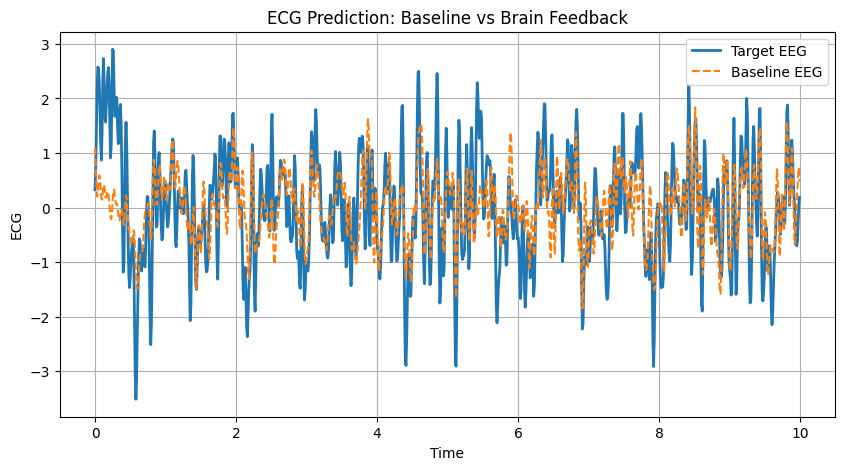

EEG_shape shape: (1000,)


In [ ]:
save_root = "/home/shobs/Desktop/DDP/multi_region_results"
os.makedirs(save_root, exist_ok=True)
cfg    = CONFIG
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Device: {device} ---")

# ── Load raw data ────────────────────────────────────────────────────────
raw      = mne.io.read_raw_fif(cfg["fif_path"], preload=True)
mat      = loadmat(cfg["mat_path"])
sc_data  = loadmat(cfg["sc_path"])
sc_matrix = sc_data["sc"]

# Structural connectivity
max_val   = np.max(sc_matrix)
Sw_all    = (sc_matrix / max_val) * cfg["sc_scale"]
thr       = np.percentile(Sw_all, cfg["sc_percentile"])
Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0.0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0] for i in range(Sw_sparse.shape[0])
]

# ── Slice full recording ─────────────────────────────────────────────────
fs_raw         = cfg["fs_raw"]
fs_model       = cfg["fs_model"]
train_sec      = cfg["train_sec"]
test_sec       = cfg["test_sec"]
total_sec      = train_sec + test_sec
start_idx      = cfg["start_idx"]
total_samples  = total_sec * fs_raw
full_slice     = slice(start_idx, start_idx + total_samples)

ecg_full = -raw[cfg["ecg_channel_idx"], full_slice][0][0]
eeg_full =  mat["Value"][:, full_slice]


ecg_full_processed = preprocess_signal(
    ecg_full, fs=fs_raw,
    lowcut=cfg["ecg_lowcut"], highcut=cfg["ecg_highcut"],
    order=cfg["butter_order"],
)
ecg_full_processed_fb = ecg_full_processed 

eeg_full_processed = np.array([
    preprocess_signal(row, fs=fs_raw,
                        lowcut=cfg["eeg_lowcut"], highcut=cfg["eeg_highcut"],
                        order=cfg["butter_order"])
    for row in eeg_full
])

# ── Train/test split ─────────────────────────────────────────────────────
train_samples_raw   = train_sec * fs_raw
train_samples_model = train_sec * fs_model
ecg_train    = ecg_full_processed[:train_samples_raw]
ecg_test  = ecg_full_processed[train_samples_raw:]
eeg_train = eeg_full_processed[:, :train_samples_raw]
eeg_test  = eeg_full_processed[:, train_samples_raw:]

target_idx = cfg["target_eeg_idx"]

# ── Time axes ────────────────────────────────────────────────────────────
t_full  = np.arange(0, total_sec, 1 / fs_model)
t_train = np.arange(0, train_sec, 1 / fs_model)
t_test = np.arange(train_sec, total_sec, 1 / fs_model) 

target_full  = eeg_full_processed[target_idx, ::10]
target_train = target_full[:train_samples_model]
target_test  = target_full[train_samples_model:]

D_full_func = interp1d(t_full, target_full,
                        kind="linear", bounds_error=False, fill_value=0.0)
regions = [cfg["target_eeg_idx"]]  # start with 1 region
regions=[1]
for r in regions:
    target_full_r = eeg_full_processed[r, ::10]
    D_full_func_r = interp1d(t_full, target_full_r,
                             kind="linear", bounds_error=False, fill_value=0.0)
    run_pipeline_for_region(
        r, cfg, raw, mat, Sw_all,
        non_zero_indices_per_row,
        ecg_full_processed,
        ecg_full_processed_fb,   # ← was ecg_full_processed twice
        eeg_full_processed,
        t_full, t_train, t_test,
        D_full_func_r,
        device, save_root,       # ← add save_root
    )

In [7]:
import numpy as np
import matplotlib.pyplot as plt

FS = 100  # sampling frequency


def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def load_all(region_dir, true_name, pred_name):
    return {
        "true_full": np.load(f"{region_dir}/{true_name}_full.npy"),
        "pred_full": np.load(f"{region_dir}/{pred_name}_full.npy"),
        "true_train": np.load(f"{region_dir}/{true_name}_train.npy"),
        "pred_train": np.load(f"{region_dir}/{pred_name}_train.npy"),
        "true_test": np.load(f"{region_dir}/{true_name}_test.npy"),
        "pred_test": np.load(f"{region_dir}/{pred_name}_test.npy"),
    }


def plot_all(region_dir):
    configs = [
        ("eeg_true", "eeg_stage1b", "EEG Stage 1b"),
        ("eeg_true", "eeg_stage2", "EEG Stage 2"),
        ("ecg_true", "ecg_stage2", "ECG Stage 2"),
        ("ecg_true", "ecg_stage4", "ECG Stage 4"),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(14, 18))

    # -------- FULL PLOTS (same as before) --------
    for i, (true_name, pred_name, title) in enumerate(configs):
        data = load_all(region_dir, true_name, pred_name)

        true_full = data["true_full"]
        pred_full = data["pred_full"]
        true_train = data["true_train"]
        pred_train = data["pred_train"]
        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # correlations
        corr_full = compute_corr(pred_full, true_full)
        corr_train = compute_corr(pred_train, true_train)
        corr_test = compute_corr(pred_test, true_test)

        # time
        T = len(true_full)
        t = np.linspace(0, T / FS, T)
        T_train = len(true_train)

        ax = axes[i]
        ax.plot(t, true_full, label="True")
        ax.plot(t, pred_full, label="Pred")

        ax.axvline(t[T_train], linestyle="--")

        ax.set_title(
            f"{title} | Full: {corr_full:.3f}, Train: {corr_train:.3f}, Test: {corr_test:.3f}"
        )
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)

        if i == 0:
            ax.legend()

    # -------- ZOOMED TEST PLOTS (1 second) --------
    zoom_configs = [
        ("eeg_true", "eeg_stage2", "EEG Test (1s)"),
        ("ecg_true", "ecg_stage4", "ECG Test (1s)"),
    ]

    for j, (true_name, pred_name, title) in enumerate(zoom_configs):
        data = load_all(region_dir, true_name, pred_name)

        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # first 1 second
        n = min(FS, len(true_test))
        t = np.linspace(0, n / FS, n)

        corr = compute_corr(pred_test[:n], true_test[:n])

        ax = axes[4 + j]
        ax.plot(t, true_test[:n], label="True")
        ax.plot(t, pred_test[:n], label="Pred")

        ax.set_title(f"{title} | Corr: {corr:.3f}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Run
region_dir = os.path.join(save_root, f"region_{region_idx}")
os.makedirs(region_dir, exist_ok=True)
plot_all(region_dir)

NameError: name 'region_idx' is not defined